In [1]:
import numpy as np
import pandas as pd
import joblib
from scipy import sparse
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

X_train = sparse.load_npz("../data/processed/X_train.npz")
X_test = sparse.load_npz("../data/processed/X_test.npz")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (7519, 438) | X_test: (2025, 438)


In [2]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_samples_leaf=3,
    random_state=42,
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [3]:
mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"MSE : {mse_gb:.4f}")
print(f"MAE : {mae_gb:.4f}")
print(f"R²  : {r2_gb:.4f}")

print("\n--- Comparaison des 3 modèles ---")
print(f"{'Métrique':<10}{'Ridge':<10}{'Random Forest':<15}{'Gradient Boosting':<18}")
print(f"{'MSE':<10}{0.0247:<10.4f}{0.0171:<15.4f}{mse_gb:<18.4f}")
print(f"{'MAE':<10}{0.1227:<10.4f}{0.0983:<15.4f}{mae_gb:<18.4f}")
print(f"{'R²':<10}{0.2067:<10.4f}{0.4513:<15.4f}{r2_gb:<18.4f}")

MSE : 0.0182
MAE : 0.1036
R²  : 0.4155

--- Comparaison des 3 modèles ---
Métrique  Ridge     Random Forest  Gradient Boosting 
MSE       0.0247    0.0171         0.0182            
MAE       0.1227    0.0983         0.1036            
R²        0.2067    0.4513         0.4155            


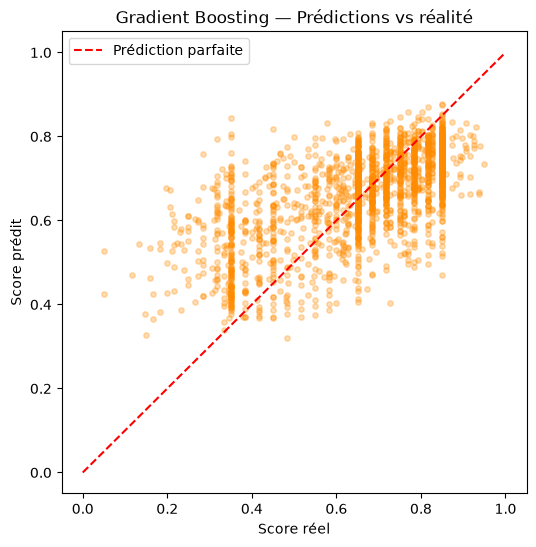

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_gb, alpha=0.3, s=15, color="darkorange")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Prédiction parfaite")
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Gradient Boosting — Prédictions vs réalité")
plt.legend()
plt.show()

In [5]:
tfidf = joblib.load("../data/processed/tfidf_vectorizer.pkl")
ohe = joblib.load("../data/processed/job_position_encoder.pkl")

numeric_cols = [
    "skills_overlap", "experience_years_min",
    "has_career_objective", "has_certifications", "has_languages",
    "has_extra_curricular", "has_skills_required",
    "has_experience_requirement", "has_age_requirement",
]

feature_names = (
    list(tfidf.get_feature_names_out())
    + list(tfidf.get_feature_names_out())
    + ["text_similarity"]
    + numeric_cols
    + list(ohe.get_feature_names_out())
)

importances = pd.Series(
    gb_model.feature_importances_,
    index=feature_names[:len(gb_model.feature_importances_)]
)

print("Top 15 features les plus importantes (Gradient Boosting) :")
print(importances.sort_values(ascending=False).head(15))

Top 15 features les plus importantes (Gradient Boosting) :
autocad                 0.142690
text_similarity         0.115383
machine learning        0.070708
management              0.034292
compliance              0.026827
has_age_requirement     0.023154
business                0.021693
quality                 0.020942
design                  0.015320
bachelor                0.015208
experience_years_min    0.014699
time                    0.013167
technical               0.012225
communication           0.010796
microsoft office        0.010120
dtype: float64


In [6]:
joblib.dump(gb_model, "../data/processed/gradient_boosting_model.pkl")
print("Modèle Gradient Boosting sauvegardé.")

Modèle Gradient Boosting sauvegardé.
